In [ ]:
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.models import Sequential
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt 


import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import pandas as pd
import numpy as np
from keras.preprocessing import image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [55]:
churn = pd.read_csv('Churn_Modelling.csv')
churn

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [56]:
churn.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [57]:
churn.duplicated().sum()

np.int64(0)

In [58]:
churn["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

<Axes: xlabel='Exited', ylabel='count'>

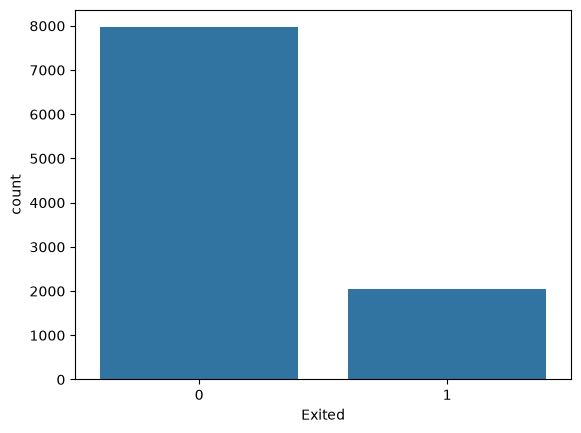

In [59]:
sns.countplot(x='Exited', data=churn)

<Axes: >

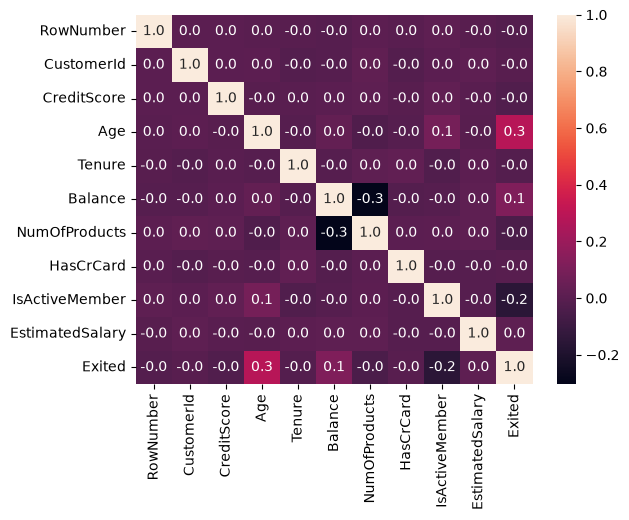

In [60]:
sns.heatmap(churn.select_dtypes(include='number').corr(), annot=True, fmt=".1f")

In [61]:
churn = churn.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [62]:
churn = pd.get_dummies(
    churn,
    columns=['Geography', 'Gender'],
    drop_first=True
)

In [63]:
churn.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [64]:
x = churn.drop('Exited',axis=1)
y = churn['Exited']

x_train, x_test, y_train, y_test = train_test_split(x,y, train_size=0.8, random_state=42, stratify=y)

In [65]:
from sklearn.preprocessing import StandardScaler

scaler_x = StandardScaler()
scaler_y = StandardScaler()

# Scale X
x_train_scaled = scaler_x.fit_transform(x_train)
x_test_scaled = scaler_x.transform(x_test)

In [66]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

print("Original features:", x_train_scaled.shape[1])
print("PCA features:", x_train_pca.shape[1])
print("Explained variance:", pca.explained_variance_ratio_.sum())

Original features: 11
PCA features: 10
Explained variance: 0.9568397539232858


In [67]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

x_train_res, y_train_res = ros.fit_resample(
    x_train_pca,
    y_train
)

print("Before oversampling:")
print(y_train.value_counts())

print("\nAfter oversampling:")
print(y_train_res.value_counts())

Before oversampling:
Exited
0    6370
1    1630
Name: count, dtype: int64

After oversampling:
Exited
1    6370
0    6370
Name: count, dtype: int64


In [68]:
#in this step we are intialising the ANN

classifier = Sequential()

In [69]:
#in this we are using activation relu so that the neuron is activated
#we are adding the first and second hidden layers
classifier.add(Dense(units=64,activation='relu'))
classifier.add(Dense(units=40,activation='relu'))
classifier.add(Dense(units=20,activation='relu'))
classifier.add(Dense(units=10,activation='relu'))
classifier.add(Dense(units=5,activation='relu'))

In [70]:
classifier.add(Dense(units=1, activation='sigmoid'))

In [71]:
classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [72]:
model_history=classifier.fit(x_train_res,y_train_res, validation_split=0.33, batch_size=100, epochs=100)

Epoch 1/100


86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6383 - loss: 0.6885 - val_accuracy: 0.1325 - val_loss: 0.7345
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7750 - loss: 0.6276 - val_accuracy: 0.1627 - val_loss: 0.8182
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7836 - loss: 0.4818 - val_accuracy: 0.4804 - val_loss: 1.0379
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8123 - loss: 0.4125 - val_accuracy: 0.4970 - val_loss: 0.8823
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8252 - loss: 0.3938 - val_accuracy: 0.5165 - val_loss: 0.8641
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8334 - loss: 0.3828 - val_accuracy: 0.5363 - val_loss: 0.8436
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8360 - loss: 0.3758 - val_accuracy: 0.5317 - val_loss: 0.8927
Epoch 8/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8404 - loss: 0.3715 - val_accuracy: 0.5981 - val_loss: 0.7

In [74]:
y_pred1 = classifier.predict(x_test_pca)
y_pred_thresholed = (y_pred1>0.5).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [75]:
cm=confusion_matrix(y_test,y_pred_thresholed)
cm

array([[1430,  163],
       [ 206,  201]])

In [76]:
ascore = accuracy_score(y_test,y_pred_thresholed)
ascore

0.8155

In [77]:
from sklearn.metrics import cohen_kappa_score
kscore=cohen_kappa_score(y_test,y_pred_thresholed)
kscore

0.40756391566535866

In [79]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(x_train_res, y_train_res)
rf_train = rf.score(x_train_res, y_train_res)
print(rf_train)
rf_predict = rf.predict(x_test_pca)
rf_predict

1.0


array([0, 0, 0, ..., 1, 0, 0], shape=(2000,))

In [80]:
rf_confusion_mat = confusion_matrix(y_test, rf_predict)
print('Confusion Matrix:\n', rf_confusion_mat)

rf_accuracy = accuracy_score(y_test, rf_predict)
print('Accuracy:\n', rf_accuracy)

rf_class_rep = classification_report(y_test, rf_predict)
print('Classification Report:\n', rf_class_rep)

Confusion Matrix:
 [[1486  107]
 [ 204  203]]
Accuracy:
 0.8445
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.93      0.91      1593
           1       0.65      0.50      0.57       407

    accuracy                           0.84      2000
   macro avg       0.77      0.72      0.74      2000
weighted avg       0.83      0.84      0.84      2000



In [83]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth' : [15, 20, 25],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'n_estimators' : [50, 100, 150]
}

#create the gridsearchcv instance
grid_search = GridSearchCV(rf, param_grid, cv=5)

#Fit the grid search to the training data
grid_search.fit(x_train_res, y_train_res)

#get the best model from grid search
best_model = grid_search.best_estimator_

#make predictions on the test set using the best model
y_pred3 = best_model.predict(x_test_pca)

#evaluate the models performance using accuracy
accuracy3 = accuracy_score(y_test, y_pred3)
print('Accuracy:\n', accuracy3)

#print the best hyperparameters found by grid search
print('Best Hyperparameters:', grid_search.best_params_)

Accuracy:
 0.847
Best Hyperparameters: {'max_depth': 25, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}


In [84]:
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb

In [85]:
gradient_boosting_model = GradientBoostingClassifier()


gradient_boosting_model.fit(x_train_res, y_train_res)


gradient_boosting_predictions = gradient_boosting_model.predict(x_test_pca)

In [86]:
grad_confusion_mat = confusion_matrix(y_test, gradient_boosting_predictions)
print('Confusion Matrix:\n', grad_confusion_mat)

grad_accuracy = accuracy_score(y_test, gradient_boosting_predictions)
print('Accuracy:\n', grad_accuracy)

grad_class_rep = classification_report(y_test, gradient_boosting_predictions)
print('Classification Report:\n', grad_class_rep)

Confusion Matrix:
 [[1285  308]
 [ 117  290]]
Accuracy:
 0.7875
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.81      0.86      1593
           1       0.48      0.71      0.58       407

    accuracy                           0.79      2000
   macro avg       0.70      0.76      0.72      2000
weighted avg       0.83      0.79      0.80      2000



In [87]:
xgboost_model = xgb.XGBClassifier()


xgboost_model.fit(x_train_res, y_train_res)
xgboost_predictions = xgboost_model.predict(x_test_pca)

In [88]:
xg_confusion_mat = confusion_matrix(y_test, xgboost_predictions)
print('Confusion Matrix:\n', xg_confusion_mat)

xg_accuracy = accuracy_score(y_test, xgboost_predictions)
print('Accuracy:\n', xg_accuracy)

xg_class_rep = classification_report(y_test, xgboost_predictions)
print('Classification Report:\n', xg_class_rep)

Confusion Matrix:
 [[1429  164]
 [ 177  230]]
Accuracy:
 0.8295
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.90      0.89      1593
           1       0.58      0.57      0.57       407

    accuracy                           0.83      2000
   macro avg       0.74      0.73      0.73      2000
weighted avg       0.83      0.83      0.83      2000

